C:\Users\elxpa\AppData\Local\Temp\ipykernel_5576\3087749948.py:13: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset([str(p) for p in files], combine='by_coords', parallel=True)


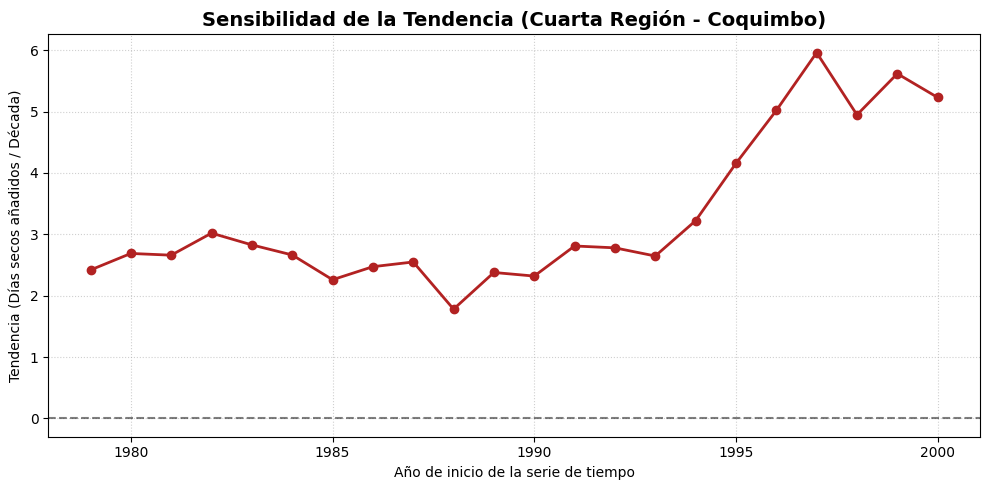

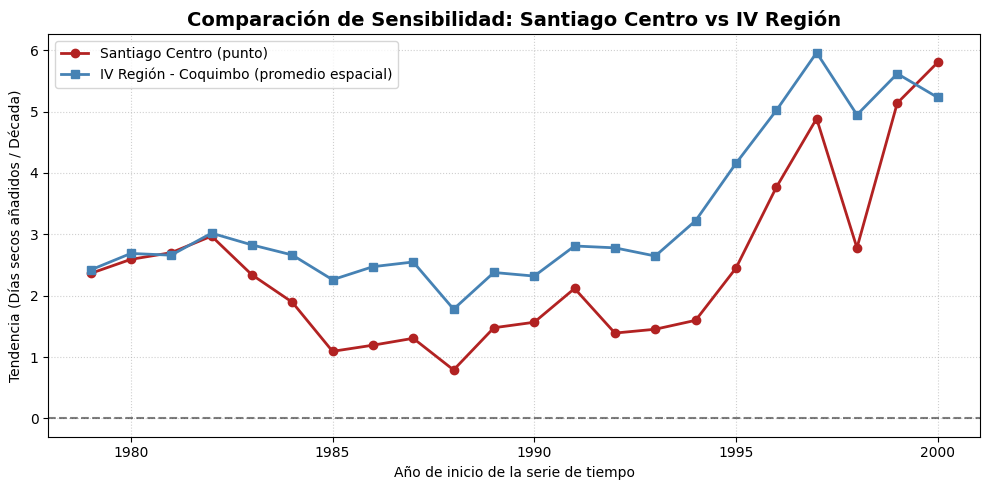

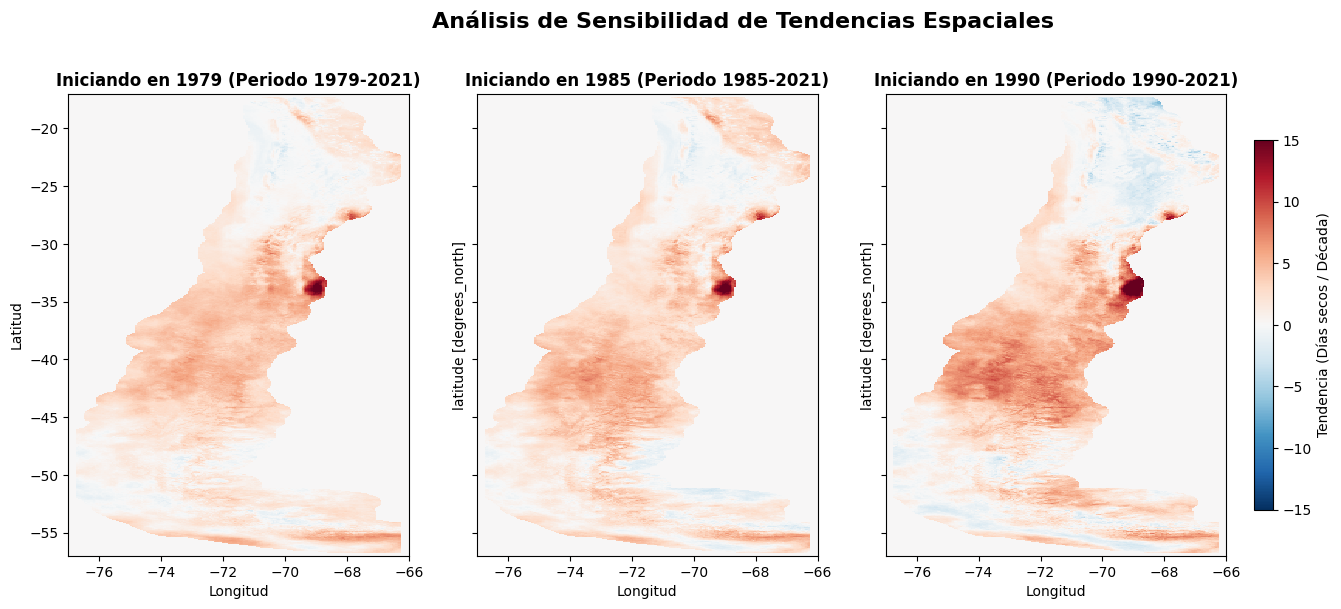

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path

# =====================================================================
# 1. CARGA DE DATOS Y CÁLCULO DE LA MÉTRICA
# =====================================================================
pr_dir = Path('pr')
files = sorted(pr_dir.glob('CR2MET_pr_v2.5_day_*.nc'))
ds = xr.open_mfdataset([str(p) for p in files], combine='by_coords', parallel=True)

# Métrica: Días secos por año (precipitación < 1.0 mm)
dry_days_per_year = (ds["pr"] < 1.0).groupby("time.year").sum(dim="time")

# =====================================================================
# 2. ANÁLISIS 1D: SENSIBILIDAD EN SANTIAGO CENTRO (punto original)
# =====================================================================
lat_sc = -33.45
lon_sc = -70.66
dry_days_sc = dry_days_per_year.sel(lat=lat_sc, lon=lon_sc, method="nearest")

anios_inicio = range(1979, 2001)
tendencias_santiago = []

for anio in anios_inicio:
    serie_recortada = dry_days_sc.sel(year=slice(anio, 2021))
    slope, intercept, r_val, p_val, std_err = linregress(serie_recortada.year, serie_recortada.values)
    tendencias_santiago.append(slope * 10)

# =====================================================================
# 3. ANÁLISIS 1D: SENSIBILIDAD EN LA CUARTA REGIÓN (promedio espacial)
# =====================================================================

# --- Bounding box Cuarta Región (Coquimbo) ---
lat_min, lat_max = -32.0, -29.0
lon_min, lon_max = -72.0, -69.0

# Extraer y promediar espacialmente
# NOTA: Si el resultado sale vacío, cambia a slice(lat_max, lat_min)
#       porque CR2MET puede tener latitudes en orden descendente
dry_days_region = (
    dry_days_per_year
    .sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    .mean(dim=["lat", "lon"])
)

tendencias_region = []

for anio in anios_inicio:
    serie_recortada = dry_days_region.sel(year=slice(anio, 2021))
    slope, intercept, r_val, p_val, std_err = linregress(serie_recortada.year, serie_recortada.values)
    tendencias_region.append(slope * 10)

# =====================================================================
# 4. GRÁFICO 1: SENSIBILIDAD CUARTA REGIÓN (solo región)
# =====================================================================
plt.figure(figsize=(10, 5))
plt.plot(anios_inicio, tendencias_region, marker='o', color='firebrick', lw=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Sensibilidad de la Tendencia (Cuarta Región - Coquimbo)", fontsize=14, fontweight='bold')
plt.xlabel("Año de inicio de la serie de tiempo")
plt.ylabel("Tendencia (Días secos añadidos / Década)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. GRÁFICO 2: COMPARACIÓN SANTIAGO CENTRO vs CUARTA REGIÓN
# =====================================================================
plt.figure(figsize=(10, 5))
plt.plot(anios_inicio, tendencias_santiago, marker='o', color='firebrick',
         lw=2, label='Santiago Centro (punto)')
plt.plot(anios_inicio, tendencias_region, marker='s', color='steelblue',
         lw=2, label='IV Región - Coquimbo (promedio espacial)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Comparación de Sensibilidad: Santiago Centro vs IV Región", fontsize=14, fontweight='bold')
plt.xlabel("Año de inicio de la serie de tiempo")
plt.ylabel("Tendencia (Días secos añadidos / Década)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# =====================================================================
# 6. ANÁLISIS 2D: SENSIBILIDAD ESPACIAL (MAPAS COMPARATIVOS)
# =====================================================================
anios_mapas = [1979, 1985, 1990]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, anio in enumerate(anios_mapas):
    ds_espacial = dry_days_per_year.sel(year=slice(anio, 2021))
    fit = ds_espacial.polyfit(dim='year', deg=1)
    slope_espacial = fit['polyfit_coefficients'].sel(degree=1)
    tendencia_decada = slope_espacial * 10

    ax = axes[i]
    im = tendencia_decada.plot(ax=ax, cmap="RdBu_r", vmin=-15, vmax=15, add_colorbar=False)
    ax.set_title(f"Iniciando en {anio} (Periodo {anio}-2021)", fontweight='bold')
    ax.set_xlabel("Longitud")
    if i == 0:
        ax.set_ylabel("Latitud")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.8, pad=0.02)
cbar.set_label('Tendencia (Días secos / Década)')
plt.suptitle("Análisis de Sensibilidad de Tendencias Espaciales", fontsize=16, fontweight='bold', y=1.02)
plt.show()